# Phase 4 — Clustering: Building the Reader Profile
## Fase 4 — Clustering: Construir el Perfil Lector

**Intelligent Personal Literary Analysis System**  
*Sistema Inteligente de Análisis Literario Personal*

---

**EN:** Groups the reader's books into thematic clusters using BERT embeddings from Phase 3.  
Each cluster represents a distinct reading pattern — a combination of themes, tone, and emotional register  
that appears repeatedly across the reader's notes.

**ES:** Agrupa los libros del lector en clusters temáticos usando los embeddings BERT de la Fase 3.  
Cada cluster representa un patrón de lectura distinto — una combinación de temas, tono y registro emocional  
que aparece de forma recurrente en las notas del lector.

**Algorithm / Algoritmo:** K-Means (unsupervised clustering)


## Step 1 — Imports and Mount Drive / Imports y Montar Drive


In [ ]:
import logging
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from google.colab import drive

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger("phase_4")

drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/Colab Notebooks/PF_Ironhack/"

logger.info("Imports complete. Drive mounted.")


Mounted at /content/drive


## Step 2 — Load Phase 3 Artifacts / Cargar Artefactos de la Fase 3

**EN:** We load the BERT embeddings and processed notes saved by Phase 3.  
**ES:** Cargamos los embeddings BERT y las notas procesadas guardadas por la Fase 3.


In [ ]:
def load_pickle(filename: str, drive_path: str) -> object:
    """Loads a pickle file from Drive. Raises FileNotFoundError if not found."""
    filepath = os.path.join(drive_path, filename)
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"{filename} not found at {filepath}. Run Phase 3 first."
        )
    with open(filepath, 'rb') as f:
        obj = pickle.load(f)
    logger.info("Loaded: %s", filename)
    return obj


bert_embeddings  = load_pickle('bert_embeddings.pkl', DRIVE_PATH)
tfidf_array      = load_pickle('tfidf_matrix.pkl',    DRIVE_PATH)
tfidf_vectorizer = load_pickle('tfidf_vectorizer.pkl', DRIVE_PATH)

notes_path = os.path.join(DRIVE_PATH, 'user_notes_processed.csv')
df_notas   = pd.read_csv(notes_path)

feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"BERT embeddings shape : {bert_embeddings.shape}")
print(f"TF-IDF matrix shape   : {tfidf_array.shape}")
print(f"Notes loaded          : {len(df_notas)}")
print()
print("Books:")
for i, title in enumerate(df_notas['title']):
    print(f"  {i+1:02d}. {title}")


BERT embeddings shape : (50, 768)
TF-IDF matrix shape   : (50, 500)
Notes loaded          : 50

Books:
  01. The Name of the Wind
  02. Dune
  03. The Little Prince
  04. 1984
  05. Sapiens
  06. The Catcher in the Rye
  07. Ubik
  08. A Supposedly Fun Thing I'll Never Do Again
  09. Man's Search for Meaning
  10. Ask the Dust
  11. Crime and Punishment
  12. Factotum
  13. Pride and Prejudice
  14. Wilt
  15. The Royal Game
  16. Perfume: The Story of a Murderer
  17. I Am Alive and You Are Dead
  18. The Man in the High Castle
  19. Confessions of a Mask
  20. Let the Right One In
  21. The Tunnel
  22. On Heroes and Tombs
  23. Frankenstein
  24. Brave New World
  25. Animal Farm
  26. The Brotherhood of the Grape
  27. One Hundred Years of Solitude
  28. The Stranger
  29. Notes from Underground
  30. Steppenwolf
  31. The Master and Margarita
  32. Nausea
  33. The Wind-Up Bird Chronicle
  34. The Remains of the Day
  35. Siddhartha
  36. Ham on Rye
  37. Flowers for Algernon
  38

## Step 3 — Dimensionality Reduction with PCA / Reducción de Dimensiones con PCA

**EN:** BERT embeddings have 768 dimensions. K-Means performs poorly in very high-dimensional spaces  
because distances between points become less informative — a phenomenon known as the  
*curse of dimensionality*. PCA compresses the embeddings into a smaller number of dimensions  
while retaining most of the relevant variance.

We fit two PCA models:
- `pca_5` — 5 components for clustering (more information retained)
- `pca_2` — 2 components for visualization only (human-readable scatter plot)

**ES:** Los embeddings BERT tienen 768 dimensiones. K-Means rinde mal en espacios muy dimensionales  
porque las distancias entre puntos se vuelven poco informativas — la *maldición de la dimensionalidad*.  
PCA comprime los embeddings conservando la mayor parte de la varianza relevante.


In [ ]:
pca_5 = PCA(n_components=5, random_state=42)
embeddings_5d = pca_5.fit_transform(bert_embeddings)

pca_2 = PCA(n_components=2, random_state=42)
embeddings_2d = pca_2.fit_transform(bert_embeddings)

variance_5d = pca_5.explained_variance_ratio_.sum() * 100
variance_2d = pca_2.explained_variance_ratio_.sum() * 100

logger.info("PCA complete. 5D variance: %.1f%% | 2D variance: %.1f%%", variance_5d, variance_2d)
print(f"5 components retain : {variance_5d:.1f}% of original variance  (used for clustering)")
print(f"2 components retain : {variance_2d:.1f}% of original variance  (used for visualization only)")


5 components retain : 27.8% of original variance  (used for clustering)
2 components retain : 13.6% of original variance  (used for visualization only)


## Step 4 — Find Optimal K: Elbow Method + Silhouette Score
## Encontrar K Óptimo: Método del Codo + Silhouette Score

**EN:** K-Means requires specifying the number of clusters K in advance.  
Two complementary metrics help identify the best value:

- **Elbow method** — plots inertia (sum of squared distances from each point to its cluster center)  
  against K.
- **Silhouette score** — measures how well-separated the clusters are (1.0 = perfect separation,  
  0 = overlapping clusters).

**ES:** K-Means requiere especificar de antemano el número de clusters K.  
Dos métricas complementarias ayudan a identificar el mejor valor:

- **Método del codo** — grafica la inercia contra K.
- **Silhouette score** — mide qué tan bien separados están los clusters.


  K=2 | Inertia: 6.4492 | Silhouette: 0.181
  K=3 | Inertia: 5.3573 | Silhouette: 0.216
  K=4 | Inertia: 4.5904 | Silhouette: 0.216
  K=5 | Inertia: 3.8322 | Silhouette: 0.235
  K=6 | Inertia: 3.0671 | Silhouette: 0.269


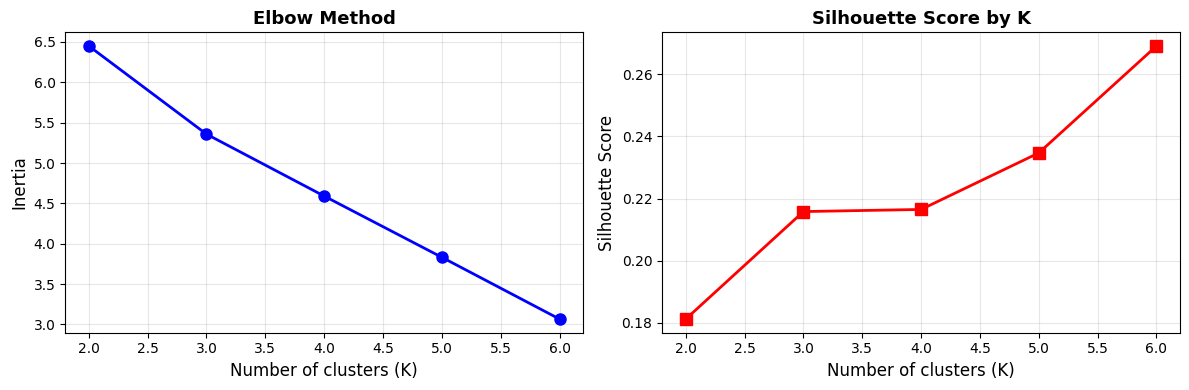


Suggested K by Silhouette Score: K=6 (score: 0.269)
Review the elbow chart and adjust K_FINAL below if needed.


In [ ]:
K_range = range(2, 7)

inertias          = []
silhouette_scores = []

for k in K_range:
    km     = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(embeddings_5d)

    inertias.append(km.inertia_)
    sil = silhouette_score(embeddings_5d, labels)
    silhouette_scores.append(sil)

    print(f"  K={k} | Inertia: {km.inertia_:.4f} | Silhouette: {sil:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score by K', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_PATH, 'elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
logger.info("Suggested K: %d (silhouette: %.3f)", best_k, max(silhouette_scores))
print()
print(f"Suggested K by Silhouette Score: K={best_k} (score: {max(silhouette_scores):.3f})")
print("Review the elbow chart and adjust K_FINAL below if needed.")


## Step 5 — Train K-Means / Entrenar K-Means

**EN:** Use the suggested K or override it based on the charts and narrative sense.  
Ask yourself: do the resulting groups reflect meaningfully different reading patterns?

**ES:** Usa el K sugerido o cámbialo según las gráficas y el sentido narrativo.  
Pregúntate: ¿los grupos resultantes reflejan patrones de lectura significativamente distintos?


In [ ]:
K_FINAL = 5  # Selected based on elbow + silhouette analysis

logger.info("Training K-Means with K=%d", K_FINAL)

kmeans         = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_5d)

df_notas['cluster'] = cluster_labels

print(f"K-Means trained. K={K_FINAL}")
print()
print("Books per cluster:")
print("-" * 50)
for c in range(K_FINAL):
    books_in_cluster = df_notas[df_notas['cluster'] == c]['title'].tolist()
    print(f"  Cluster {c} ({len(books_in_cluster)} books): {', '.join(books_in_cluster)}")


K-Means trained. K=5

Books per cluster:
--------------------------------------------------
  Cluster 0 (19 books): Ask the Dust, Crime and Punishment, Factotum, Wilt, Confessions of a Mask, The Tunnel, On Heroes and Tombs, The Brotherhood of the Grape, One Hundred Years of Solitude, The Stranger, Notes from Underground, The Master and Margarita, Nausea, The Wind-Up Bird Chronicle, The Remains of the Day, Ham on Rye, Chronicle of a Death Foretold, Woman at Point Zero, Don Quixote
  Cluster 1 (11 books): Dune, Sapiens, Ubik, A Supposedly Fun Thing I'll Never Do Again, Man's Search for Meaning, I Am Alive and You Are Dead, The Man in the High Castle, Flowers for Algernon, The Martian Chronicles, The Illustrated Man, Story of Your Life
  Cluster 2 (5 books): 1984, The Catcher in the Rye, Frankenstein, Brave New World, Animal Farm
  Cluster 3 (8 books): The Name of the Wind, The Little Prince, Pride and Prejudice, The Royal Game, Perfume: The Story of a Murderer, Steppenwolf, Siddhartha, T

## Step 6 — Build Reader Profile / Construir Perfil Lector

**EN:** For each cluster we compute a **centroid vector**: the average of all BERT embeddings  
in that group. This centroid is the mathematical representation of that reading pattern.

In Phase 5, these centroids will be compared against the catalog book descriptions  
to find the most similar titles.

**ES:** Para cada cluster calculamos un **vector centroide**: el promedio de todos los embeddings BERT  
de ese grupo. Este centroide es la representación matemática de ese patrón de lectura.

En la Fase 5, estos centroides se compararán contra las 9,532 descripciones del catálogo  
para encontrar los títulos más similares.


In [ ]:
reader_profile = {}

for c in range(K_FINAL):
    idx    = df_notas[df_notas['cluster'] == c].index.tolist()
    books  = df_notas.loc[idx, 'title'].tolist()

    # BERT centroid: mean of cluster embeddings
    # bert_embeddings is already L2-normalized
    centroid = bert_embeddings[idx].mean(axis=0)

    ratings    = pd.to_numeric(df_notas.loc[idx, 'rating'], errors='coerce')
    avg_rating = ratings.mean()

    # Top TF-IDF terms for this cluster — used for cluster labeling and visualization
    tfidf_cluster = tfidf_array[idx].mean(axis=0)
    top_word_idx  = tfidf_cluster.argsort()[::-1][:6]
    top_words     = [feature_names[i] for i in top_word_idx if tfidf_cluster[i] > 0]

    all_tags = []
    for tags_cell in df_notas.loc[idx, 'tags'].dropna():
        all_tags.extend([t.strip() for t in str(tags_cell).split(',') if t.strip()])
    top_tags = pd.Series(all_tags).value_counts().head(4).index.tolist() if all_tags else []

    reader_profile[f'cluster_{c}'] = {
        'cluster_id': c,
        'books':      books,
        'n_books':    len(books),
        'centroid':   centroid,
        'avg_rating': round(avg_rating, 2),
        'top_words':  top_words,
        'top_tags':   top_tags,
    }

    print(f"Cluster {c}  ({len(books)} books)")
    print(f"  Books      : {', '.join(books)}")
    print(f"  Avg rating : {avg_rating:.1f} / 5.0")
    print(f"  Keywords   : {', '.join(top_words)}")
    print(f"  Top tags   : {', '.join(top_tags)}")
    print()

logger.info("Reader profile built. %d clusters.", K_FINAL)


Cluster 0  (19 books)
  Books      : Ask the Dust, Crime and Punishment, Factotum, Wilt, Confessions of a Mask, The Tunnel, On Heroes and Tombs, The Brotherhood of the Grape, One Hundred Years of Solitude, The Stranger, Notes from Underground, The Master and Margarita, Nausea, The Wind-Up Bird Chronicle, The Remains of the Day, Ham on Rye, Chronicle of a Death Foretold, Woman at Point Zero, Don Quixote
  Avg rating : 4.7 / 5.0
  Keywords   : identity, feel, kind, self, honesty, realism
  Top tags   : identity, psychological, magical-realism, classic

Cluster 1  (11 books)
  Books      : Dune, Sapiens, Ubik, A Supposedly Fun Thing I'll Never Do Again, Man's Search for Meaning, I Am Alive and You Are Dead, The Man in the High Castle, Flowers for Algernon, The Martian Chronicles, The Illustrated Man, Story of Your Life
  Avg rating : 4.8 / 5.0
  Keywords   : history, reality, science fiction, science, fiction, scifi
  Top tags   : scifi, science-fiction, short-stories, philosophical

Clus

In [ ]:
# -------------------------------------------------------
# Assign narrative labels — fill in after reviewing the
# cluster output above and understanding which books
# ended up in each group.
# -------------------------------------------------------
CLUSTER_LABELS = {
    0: "Inner Worlds",
    1: "Speculative Minds",
    2: "Political & Dystopian",
    3: "The Seeker's Path",
    4: "The Dark & The Strange",
}

NOISE_WORDS = {"like", "experience", "just", "also", "feel", "feels", "poe", "orwel"}

for key, cluster in reader_profile.items():
    cid = cluster["cluster_id"]
    cluster["label"]     = CLUSTER_LABELS.get(cid, f"Cluster {cid}")
    cluster["top_words"] = [
        w for w in cluster["top_words"]
        if w.lower() not in NOISE_WORDS
    ]

logger.info("Labels and noise filtering applied to reader_profile.")

## Step 7 — Visualization: Book Cluster Map / Visualización: Mapa de Clusters

**EN:** Scatter plot of all books in 2D PCA space, colored by cluster.  
Books in the same cluster appear in the same color.  
This chart will be displayed in the Streamlit app (Phase 7).

**ES:** Gráfica de dispersión de todos los libros en el espacio PCA 2D, coloreados por cluster.  
Los libros del mismo cluster aparecen del mismo color.  
Esta gráfica se mostrará en la app Streamlit (Fase 7).


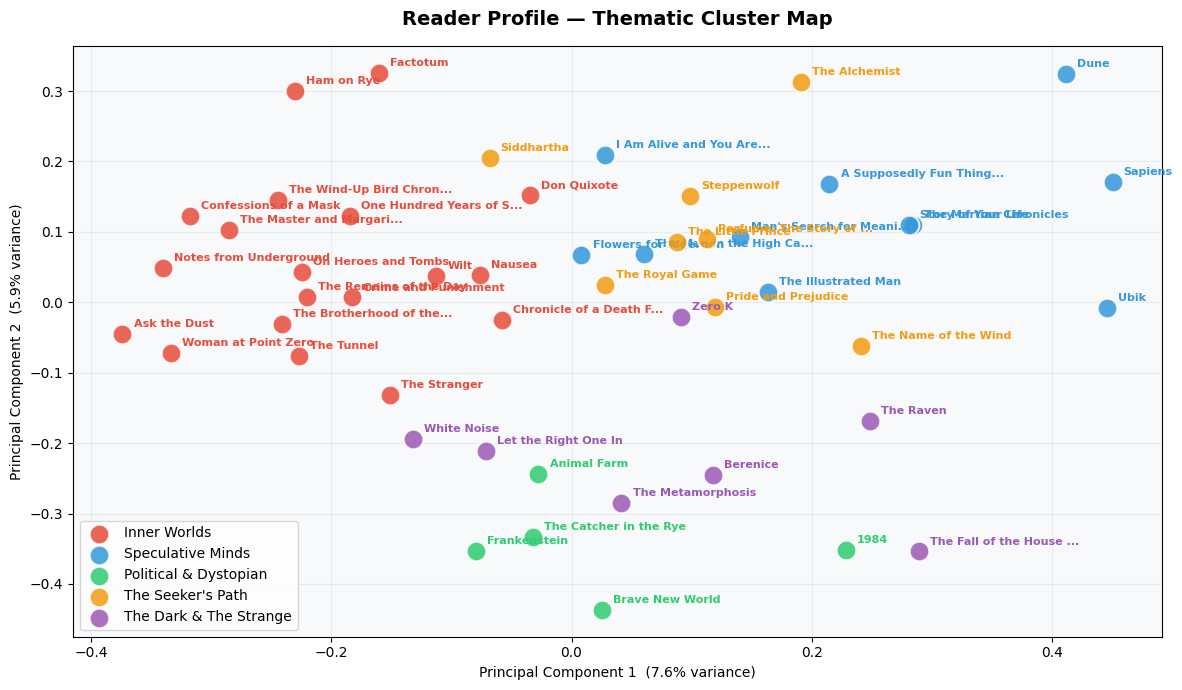

In [ ]:
CLUSTER_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']

fig, ax = plt.subplots(figsize=(12, 7))

for c in range(K_FINAL):
    idx = df_notas[df_notas['cluster'] == c].index.tolist()
    x   = embeddings_2d[idx, 0]
    y   = embeddings_2d[idx, 1]

    ax.scatter(
        x, y,
        c=CLUSTER_COLORS[c],
        s=200,
        label=reader_profile[f'cluster_{c}'].get('label', f'Cluster {c}'),
        alpha=0.85,
        edgecolors='white',
        linewidth=1.5,
        zorder=3
    )

    for row_idx in idx:
        title       = df_notas.loc[row_idx, 'title']
        short_title = title[:22] + '...' if len(title) > 22 else title
        ax.annotate(
            short_title,
            (embeddings_2d[row_idx, 0], embeddings_2d[row_idx, 1]),
            textcoords='offset points',
            xytext=(8, 5),
            fontsize=8,
            color=CLUSTER_COLORS[c],
            fontweight='bold'
        )

ax.set_title('Reader Profile — Thematic Cluster Map', fontsize=14, fontweight='bold', pad=15)
var_pc1 = pca_2.explained_variance_ratio_[0] * 100
var_pc2 = pca_2.explained_variance_ratio_[1] * 100

ax.set_xlabel(f'Principal Component 1  ({var_pc1:.1f}% variance)', fontsize=10)
ax.set_ylabel(f'Principal Component 2  ({var_pc2:.1f}% variance)', fontsize=10)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.2)
ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plot_path = os.path.join(DRIVE_PATH, 'cluster_map.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

logger.info("Cluster map saved to: %s", plot_path)


## Step 8 — Save Artifacts / Guardar Artefactos

**EN:** Saves all Phase 4 outputs to Drive.  
**ES:** Guarda todos los outputs de la Fase 4 en Drive.


In [ ]:
def save_pickle(obj: object, filename: str, drive_path: str) -> None:
    """Serializes an object to a pickle file and logs the result."""
    filepath = os.path.join(drive_path, filename)
    with open(filepath, 'wb') as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(filepath) / 1024
    logger.info("Saved: %s (%.1f KB)", filename, size_kb)
    print(f"  {filename:<35} {size_kb:.1f} KB")


print("Saving artifacts to Drive...")
print("-" * 50)
save_pickle(kmeans,         'cluster_model.pkl',  DRIVE_PATH)
save_pickle(reader_profile, 'reader_profile.pkl', DRIVE_PATH)
save_pickle(pca_5,          'pca_model.pkl',      DRIVE_PATH)

clustered_path = os.path.join(DRIVE_PATH, 'user_notes_clustered.csv')
df_notas.to_csv(clustered_path, index=False)
print(f"  {'user_notes_clustered.csv':<35} saved ({len(df_notas)} rows)")

print()
print("Verification — files in Drive:")
print("-" * 50)
for fname in ['cluster_model.pkl', 'reader_profile.pkl', 'pca_model.pkl', 'user_notes_clustered.csv']:
    path   = os.path.join(DRIVE_PATH, fname)
    status = "OK     " if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {fname}")


Saving artifacts to Drive...
--------------------------------------------------
  cluster_model.pkl                   0.9 KB
  reader_profile.pkl                  17.3 KB
  pca_model.pkl                       18.8 KB
  user_notes_clustered.csv            saved (50 rows)

Verification — files in Drive:
--------------------------------------------------
  [OK     ] cluster_model.pkl
  [OK     ] reader_profile.pkl
  [OK     ] pca_model.pkl
  [OK     ] user_notes_clustered.csv
